<a href="https://colab.research.google.com/github/Luyao-Xu/3-Class-Speech-Command-Classification/blob/main/03_DL_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup: Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
base_path    = '/content/drive/MyDrive/speech_commands_project'
log_path     = '/content/drive/MyDrive/speech_commands_project/logs'
results_path = '/content/drive/MyDrive/speech_commands_project/results'

os.makedirs(log_path,     exist_ok=True)
os.makedirs(results_path, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install "numpy <2.0.0"
!pip install -q tf_keras
!pip install -q tensorflow-model-optimization
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tensorflow as tf
import tf_keras
from tf_keras import layers, models
from tf_keras.optimizers import Adam
import tensorflow_model_optimization as tfmot

In [ ]:
# Description: Comparison of Standard CNN, SqueezeNet, and UltraLight with QAT/PTQ
# Author: [Xu Luyao]
config = {
    "version":              "1.2.0",
    "input_shape":          (40, 32, 1),
    "num_classes":          3,
    "batch_size":           32,
    "initial_epochs":       30,
    "qat_fine_tune_epochs": 8,
    "learning_rate_base":   0.001,
    "learning_rate_qat":    1e-5,
    "random_seed":          42
}
tf.random.set_seed(config["random_seed"])
np.random.seed(config["random_seed"])

## Data Loading and Reshaping
Reshape for CNN: (Samples, Height, Width, Channels) — MFCCs are 40×32

In [ ]:
processed_path = '/content/drive/MyDrive/speech_commands_project/data/processed'

X_train = np.load(os.path.join(processed_path, 'X_train.npy'))
y_train = np.load(os.path.join(processed_path, 'y_train.npy'))
X_val   = np.load(os.path.join(processed_path, 'X_val.npy'))
y_val   = np.load(os.path.join(processed_path, 'y_val.npy'))
X_test  = np.load(os.path.join(processed_path, 'X_test.npy'))
y_test  = np.load(os.path.join(processed_path, 'y_test.npy'))

X_train = X_train.reshape(X_train.shape[0], 40, 32, 1)
X_val   = X_val.reshape(X_val.shape[0],     40, 32, 1)
X_test  = X_test.reshape(X_test.shape[0],   40, 32, 1)

print(f"Data ready for CNN. Train shape: {X_train.shape}")

Data ready for CNN. Train shape: (7492, 40, 32, 1)


#### Model A: Simple 2D CNN (Baseline)

In [ ]:
def build_simple_cnn_for_qat(input_shape, num_classes):
    return tf_keras.Sequential([
        tf_keras.layers.Input(shape=input_shape),
        tf_keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf_keras.layers.MaxPooling2D((2, 2)),
        tf_keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf_keras.layers.MaxPooling2D((2, 2)),
        tf_keras.layers.Flatten(),
        tf_keras.layers.Dense(64, activation='relu'),
        tf_keras.layers.Dropout(0.3),
        tf_keras.layers.Dense(3, activation='softmax')
    ])

model_a = build_simple_cnn_for_qat((40, 32, 1), 3)
model_a.compile(
    optimizer=tf_keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_a.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 38, 30, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 19, 15, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 17, 13, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 8, 6, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 3072)              0         
                                                                 
 dense (Dense)               (None, 64)                1

### Model B: Mini-SqueezeNet
Uses Fire Modules (Squeeze & Expand). Shows how 1×1 convolutions

In [ ]:
def fire_module(x, squeeze, expand):
    s  = layers.Conv2D(squeeze, (1, 1), padding='same', activation='relu')(x)
    e1 = layers.Conv2D(expand,  (1, 1), padding='same', activation='relu')(s)
    e3 = layers.Conv2D(expand,  (3, 3), padding='same', activation='relu')(s)
    return layers.Concatenate()([e1, e3])

def build_squeezenet(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(16, (3, 3), strides=(1, 1), padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = fire_module(x, squeeze=8,  expand=16)
    x = fire_module(x, squeeze=8,  expand=16)
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name="Model_B_SqueezeNet")

model_b = build_squeezenet((40, 32, 1), 3)
model_b.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_b.summary()

Model: "Model_B_SqueezeNet"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 40, 32, 1)]          0         []                            
                                                                                                  
 conv2d_2 (Conv2D)           (None, 40, 32, 16)           160       ['input_2[0][0]']             
                                                                                                  
 max_pooling2d_2 (MaxPoolin  (None, 20, 16, 16)           0         ['conv2d_2[0][0]']            
 g2D)                                                                                             
                                                                                                  
 conv2d_3 (Conv2D)           (None, 20, 16, 8)            136       ['max_pooling

### Model C: Ultra-Lightweight (MobileNet-style)
MobileNet-inspired. Uses Depthwise Separable Convolutions and
Global Average Pooling instead of Flatten.

In [ ]:
def build_ultralight_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Block 1: Feature Extraction
        layers.SeparableConv2D(16, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Block 2: Feature Extraction
        layers.SeparableConv2D(32, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Embedded Trick: Global Average Pooling instead of Flatten
        layers.GlobalAveragePooling2D(),

        # Classification Head
        layers.Dense(32,           activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes,  activation='softmax')
    ])
    return model

model_c = build_ultralight_cnn((40, 32, 1), 3)
model_c.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_c.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 separable_conv2d (Separabl  (None, 40, 32, 16)        41        
 eConv2D)                                                        
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 20, 16, 16)        0         
 g2D)                                                            
                                                                 
 separable_conv2d_1 (Separa  (None, 20, 16, 32)        688       
 bleConv2D)                                                      
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 10, 8, 32)         0         
 g2D)                                                            
                                                                 
 global_average_pooling2d_1  (None, 32)               

## **Training**
##### FIX: Model A was designed for lr=0.0001 (10x lower than B/C).
Original code overrode all models to 0.001, losing Model A's tuned lr. This map preserves each model's intended learning rate.

In [ ]:
models_to_train = {
    "Model_A_Standard":  model_a,
    "Model_B_Separable": model_b,
    "Model_C_UltraLight":model_c
}

EPOCHS        = config["initial_epochs"]
BATCH_SIZE    = config["batch_size"]

model_lr_map = {
    "Model_A_Standard":  0.0001,  # as defined in build_simple_cnn_for_qat
    "Model_B_Separable": 0.001,
    "Model_C_UltraLight":0.001,
}

histories      = {}
training_times = {}
training_summary_rows = []

for name, model in models_to_train.items():
    print(f"\n{'='*50}")
    print(f" Starting Training: {name}")
    print(f"{'='*50}")

    lr = model_lr_map[name]
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    start_train = time.time()
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val),
        verbose=1
    )
    end_train = time.time()

    training_times[name] = round(end_train - start_train, 2)
    histories[name]      = history

    history_df  = pd.DataFrame(history.history)
    history_csv = os.path.join(log_path, f"{name}_training_log.csv")
    history_df.to_csv(history_csv, index=False)
    print(f" Per-epoch log saved to {history_csv}")

    training_summary_rows.append({
        "Model":              name,
        "Total Parameters":   model.count_params(),
        "Epochs":             EPOCHS,
        "Batch Size":         BATCH_SIZE,
        "Learning Rate":      lr,
        "Train Time (sec)":   training_times[name],
        "Final Train Acc":    round(history.history['accuracy'][-1],     4),
        "Final Val Acc":      round(history.history['val_accuracy'][-1], 4),
        "Timestamp":          time.strftime("%Y-%m-%d %H:%M:%S")
    })
    print(f" {name} training complete. Time: {training_times[name]:.2f}s")

training_summary_df  = pd.DataFrame(training_summary_rows)
training_summary_csv = os.path.join(log_path, 'training_summary_log.csv')
training_summary_df.to_csv(training_summary_csv, index=False)
print(f"\n Training summary log saved to {training_summary_csv}")



 Starting Training: Model_A_Standard
Epoch 1/30
235/235 [==============================] - 9s 38ms/step - loss: 0.0288 - accuracy: 0.9913 - val_loss: 0.3542 - val_accuracy: 0.9039
Epoch 2/30
235/235 [==============================] - 13s 56ms/step - loss: 0.0249 - accuracy: 0.9931 - val_loss: 0.3725 - val_accuracy: 0.9157
Epoch 3/30
235/235 [==============================] - 16s 68ms/step - loss: 0.0238 - accuracy: 0.9941 - val_loss: 0.3563 - val_accuracy: 0.9082
Epoch 4/30
235/235 [==============================] - 8s 33ms/step - loss: 0.0209 - accuracy: 0.9952 - val_loss: 0.3647 - val_accuracy: 0.9125
Epoch 5/30
235/235 [==============================] - 17s 73ms/step - loss: 0.0232 - accuracy: 0.9939 - val_loss: 0.2932 - val_accuracy: 0.9242
Epoch 6/30
235/235 [==============================] - 8s 32ms/step - loss: 0.0233 - accuracy: 0.9929 - val_loss: 0.3229 - val_accuracy: 0.9178
Epoch 7/30
235/235 [==============================] - 12s 53ms/step - loss: 0.0239 - accuracy: 0.9927

### Baseline Models to TFLite (float32, no quantization)
 By converting every model to TFLite to make all models go through the exact same measurement path.(For easier comparison)
 ##### convert to TFLite — NO optimizations = pure float32 baseline: This means weights and activations stay as 32-bit floats. It is the true reference: no compression, no accuracy loss from quant.

In [ ]:
baseline_metadata  = []
baseline_log_rows  = []

for name, model in models_to_train.items():
    print(f"\n Exporting Baseline to TFLite (float32): {name}")
    total_params = model.count_params()
    t_start = time.time()

    saved_path = os.path.join(results_path, f'{name}_baseline_saved')
    model.export(saved_path)

    converter   = tf.lite.TFLiteConverter.from_saved_model(saved_path)
    tflite_model = converter.convert()

    t_elapsed = round(time.time() - t_start, 2)

    file_path = os.path.join(results_path, f'{name}_baseline.tflite')
    with open(file_path, 'wb') as f:
        f.write(tflite_model)

    file_kb = round(len(tflite_model) / 1024, 2)
    print(f"  Saved: {file_path}  ({file_kb} KB)  Export time: {t_elapsed}s")

    # Record
    baseline_metadata.append({
        "Model":            name,
        "Type":             "Baseline",
        "Total Parameters": total_params,
        "path":             file_path
    })

    baseline_log_rows.append({
        "Model":             name,
        "Type":              "Baseline",
        "Total Parameters":  total_params,
        "Export Time (sec)": t_elapsed,
        "TFLite Size (KB)":  file_kb,
        "SavedModel Path":   saved_path,
        "TFLite Path":       file_path,
        "Timestamp":         time.strftime("%Y-%m-%d %H:%M:%S")
    })

baseline_log_df  = pd.DataFrame(baseline_log_rows)
baseline_log_csv = os.path.join(log_path, 'baseline_export_log.csv')
baseline_log_df.to_csv(baseline_log_csv, index=False)
print(f"\n Baseline process log saved to {baseline_log_csv}")

baseline_summary_df  = baseline_log_df[["Model", "Type", "Total Parameters",
                                         "TFLite Size (KB)", "Export Time (sec)"]]
baseline_summary_csv = os.path.join(results_path, 'baseline_export_summary.csv')
baseline_summary_df.to_csv(baseline_summary_csv, index=False)
print(f" Baseline file-size summary saved to {baseline_summary_csv}")


 Exporting Baseline to TFLite (float32): Model_A_Standard
Saved artifact at '/content/drive/MyDrive/speech_commands_project/results/Model_A_Standard_baseline_saved'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 40, 32, 1), dtype=tf.float32, name='input_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133641509786384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133641509787920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133641509786960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133641509788688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133641509788112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133641509789072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133641509788496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133641509789648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  Saved: /content/drive/MyDrive/sp

## **Post-Training Quantization (PTQ)**
##### Set 200 samples for better int8 calibration.
more samples = more accurate quantization ranges.

In [ ]:
ptq_metadata = []

def representative_data_gen():

    for i in range(200):
        data = np.expand_dims(X_train[i], axis=0).astype(np.float32)
        yield [data]

for name, model in models_to_train.items():
    print(f"\n Processing PTQ: {name}")
    total_params = model.count_params()   # stored as int, not string

    try:
        start_ptq = time.time()

        saved_model_path = os.path.join(results_path, f'{name}_ptq_saved')
        model.export(saved_model_path)

        converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
        converter.optimizations             = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset    = representative_data_gen
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type      = tf.float32
        converter.inference_output_type     = tf.float32

        tflite_model = converter.convert()
        ptq_duration = round(time.time() - start_ptq, 2)

        file_path = os.path.join(results_path, f'{name}_ptq.tflite')
        with open(file_path, 'wb') as f:
            f.write(tflite_model)

        file_kb = round(len(tflite_model) / 1024, 2)

        ptq_metadata.append({
            "Model":             name,
            "Type":              "PTQ",
            "Total Parameters":  total_params,
            "Conversion Time (sec)": ptq_duration,
            "TFLite Size (KB)":  file_kb,
            "path":              file_path,
            "Timestamp":         time.strftime("%Y-%m-%d %H:%M:%S")
        })
        print(f"  {name} PTQ saved. ({file_kb} KB)  Time: {ptq_duration:.2f}s")

    except Exception as e:
        print(f"  Error converting {name}: {str(e)}")

ptq_log_df  = pd.DataFrame(ptq_metadata)
ptq_log_csv = os.path.join(log_path, 'ptq_process_summary.csv')
ptq_log_df.drop(columns=["path"]).to_csv(ptq_log_csv, index=False)
print(f"\n PTQ process log saved in {ptq_log_csv}")


 Processing PTQ: Model_A_Standard
Saved artifact at '/content/drive/MyDrive/speech_commands_project/results/Model_A_Standard_ptq_saved'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 40, 32, 1), dtype=tf.float32, name='input_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133641509786384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133641509787920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133641509786960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133641509788688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133641509788112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133641509789072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133641509788496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133641509789648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  Model_A_Standard PTQ saved. (218.95 KB)  Time: 3.47s

 Proces

## **Quantization-Aware Training (QAT)**
##### Wrap each trained model with fake-quantization nodes for QAT fine-tuning.
##### quantize_model() inserts Q/DQ (quantize/dequantize) ops so the model
##### learns to be robust to int8 rounding during the fine-tune phase.

In [ ]:
qat_metadata  = []
qat_tflite_files = {}

qat_models = {
    "Model_A_Standard":  tfmot.quantization.keras.quantize_model(model_a),
    "Model_B_Separable": tfmot.quantization.keras.quantize_model(model_b),
    "Model_C_UltraLight":tfmot.quantization.keras.quantize_model(model_c)
}

for name, q_model in qat_models.items():
    print(f"\n{'='*50}")
    print(f" Starting QAT Fine-tuning: {name}")
    print(f"{'='*50}")
    total_params = q_model.count_params()

    q_model.compile(
        optimizer=tf_keras.optimizers.Adam(learning_rate=config["learning_rate_qat"]),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    start_train = time.time()
    history = q_model.fit(
        X_train, y_train,
        epochs=config["qat_fine_tune_epochs"],
        batch_size=config["batch_size"],
        validation_data=(X_val, y_val),
        verbose=1
    )
    train_duration = round(time.time() - start_train, 2)

    qat_history_csv = os.path.join(log_path, f"{name}_qat_history.csv")
    pd.DataFrame(history.history).to_csv(qat_history_csv, index=False)
    print(f" Per-epoch QAT history log saved in {qat_history_csv}")

    # Convert QAT model to TFLite
    saved_qat_path = os.path.join(results_path, f'{name}_qat_saved')
    q_model.export(saved_qat_path)

    converter = tf.lite.TFLiteConverter.from_saved_model(saved_qat_path)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_qat_model = converter.convert()

    file_path = os.path.join(results_path, f'{name}_qat.tflite')
    with open(file_path, 'wb') as f:
        f.write(tflite_qat_model)

    file_kb = round(len(tflite_qat_model) / 1024, 2)
    qat_tflite_files[name] = file_path

    qat_metadata.append({
        "Model":                name,
        "Type":                 "QAT",
        "Total Parameters":     total_params,   # int
        "Train Time (sec)":     train_duration,
        "TFLite Size (KB)":     file_kb,
        "path":                 file_path,
        "Final QAT Val Acc":    round(history.history['val_accuracy'][-1], 4),
        "Timestamp":            time.strftime("%Y-%m-%d %H:%M:%S")
    })
    print(f"  {name} QAT saved. ({file_kb} KB)  Time: {train_duration:.2f}s")

qat_log_df  = pd.DataFrame(qat_metadata)
qat_log_csv = os.path.join(log_path, 'qat_process_summary.csv')
qat_log_df.drop(columns=["path"]).to_csv(qat_log_csv, index=False)
print(f"\n QAT process log saved to {qat_log_csv}")


 Starting QAT Fine-tuning: Model_A_Standard
Epoch 1/8
235/235 [==============================] - 11s 44ms/step - loss: 0.2853 - accuracy: 0.9064 - val_loss: 0.4731 - val_accuracy: 0.8709
Epoch 2/8
235/235 [==============================] - 10s 44ms/step - loss: 0.0294 - accuracy: 0.9905 - val_loss: 0.3575 - val_accuracy: 0.9168
Epoch 3/8
235/235 [==============================] - 10s 43ms/step - loss: 0.0096 - accuracy: 0.9977 - val_loss: 0.3522 - val_accuracy: 0.9210
Epoch 4/8
235/235 [==============================] - 9s 38ms/step - loss: 0.0085 - accuracy: 0.9984 - val_loss: 0.3659 - val_accuracy: 0.9221
Epoch 5/8
235/235 [==============================] - 10s 43ms/step - loss: 0.0058 - accuracy: 0.9988 - val_loss: 0.3782 - val_accuracy: 0.9178
Epoch 6/8
235/235 [==============================] - 10s 44ms/step - loss: 0.0054 - accuracy: 0.9993 - val_loss: 0.3861 - val_accuracy: 0.9221
Epoch 7/8
235/235 [==============================] - 10s 43ms/step - loss: 0.0055 - accuracy: 0.99

## **Evaluation**

### Unified Metric Function
flash_size_kb= file bytes on disk (what "Model Size / Flash" means)

memory_ram_kb= peak activation tensor RAM during inference

params= parameter count (from metadata, not re-counted here)

accuracy= test-set accuracy, counted sample-by-sample

runtime_ms= total inference wall-clock / N = CPU throughput per sample

latency_ms= median of 50 single-sample timings (real per-call cost)

efficiency_score= composite: Acc(%) / (latency × √flash)

    Parameters
    file_path       : str   — path to the .tflite file
    X_test          : ndarray — test inputs, shape (N, 40, 32, 1)
    y_test          : ndarray — test labels, shape (N,)
    n_warmup        : int   — warm-up calls before timing (removes cold-start bias)
    n_latency_runs  : int   — how many single-sample calls to median over

    Returns dict of 6 float metrics

In [ ]:
def measure_tflite_model(file_path, X_test, y_test, n_warmup=5, n_latency_runs=50):

    flash_size_kb = os.path.getsize(file_path) / 1024

    interpreter = tf.lite.Interpreter(model_path=file_path, num_threads=1)
    interpreter.allocate_tensors()
    input_details  = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]


    tensor_details = interpreter.get_tensor_details()
    activation_bytes = sum(
        np.prod(t['shape']) * np.dtype(t['dtype']).itemsize
        for t in tensor_details
        if len(t['shape']) > 0
    )
    memory_ram_kb = activation_bytes / 1024

    for i in range(n_warmup):
        sample = X_test[i:i+1].astype(np.float32)
        interpreter.set_tensor(input_details['index'], sample)
        interpreter.invoke()


    latency_times = []
    for i in range(n_latency_runs):
        idx    = i % len(X_test)
        sample = X_test[idx:idx+1].astype(np.float32)
        t0 = time.perf_counter()
        interpreter.set_tensor(input_details['index'], sample)
        interpreter.invoke()
        _ = interpreter.get_tensor(output_details['index'])
        latency_times.append((time.perf_counter() - t0) * 1000)
    latency_ms = float(np.median(latency_times))


    correct = 0
    t_start = time.perf_counter()
    for i in range(len(X_test)):
        sample = X_test[i:i+1].astype(np.float32)
        interpreter.set_tensor(input_details['index'], sample)
        interpreter.invoke()
        pred = interpreter.get_tensor(output_details['index'])
        if np.argmax(pred) == y_test[i]:
            correct += 1
    t_end = time.perf_counter()

    accuracy   = correct / len(X_test)
    runtime_ms = ((t_end - t_start) / len(X_test)) * 1000


    acc_pct          = accuracy * 100
    efficiency_score = acc_pct / (latency_ms * (flash_size_kb ** 0.5) + 1e-9)

    return {
        "Flash Size (KB)":   round(flash_size_kb, 2),
        "Memory RAM (KB)":   round(memory_ram_kb, 2),
        "Accuracy":          round(accuracy, 4),
        "Runtime CPU (ms)":  round(runtime_ms, 4),
        "Latency (ms)":      round(latency_ms, 4),
        "Efficiency Score":  round(efficiency_score, 4),
    }

### Models benchmarked
 Baseline / PTQ / QAT each get their own clean results file

In [ ]:
all_results        = []
benchmark_log_rows = []

# Merge all entries (Baseline + PTQ + QAT) into one list
all_entries = []
for entry in baseline_metadata:
    all_entries.append(entry)
if 'ptq_metadata' in globals() and ptq_metadata:
    for entry in ptq_metadata:
        all_entries.append(entry)
if 'qat_metadata' in globals() and qat_metadata:
    for entry in qat_metadata:
        all_entries.append(entry)

#  Run models by the SAME function
for entry in all_entries:
    print(f"\n Benchmarking: {entry['Model']} [{entry['Type']}]")
    t_bench_start = time.time()

    metrics = measure_tflite_model(entry["path"], X_test, y_test)

    t_bench_elapsed = round(time.time() - t_bench_start, 2)

    row = {
        "Model":      entry["Model"],
        "Type":       entry["Type"],
        "Parameters": entry["Total Parameters"],
        **metrics
    }
    all_results.append(row)

    # Detailed log
    benchmark_log_rows.append({
        **row,
        "TFLite Path":          entry["path"],
        "Benchmark Time (sec)": t_bench_elapsed,
        "Timestamp":            time.strftime("%Y-%m-%d %H:%M:%S")
    })

    print(f"   Acc={metrics['Accuracy']:.2%}  "
          f"Latency={metrics['Latency (ms)']:.3f}ms  "
          f"Runtime={metrics['Runtime CPU (ms)']:.4f}ms  "
          f"Flash={metrics['Flash Size (KB)']:.1f}KB  "
          f"RAM={metrics['Memory RAM (KB)']:.1f}KB  "
          f"Score={metrics['Efficiency Score']:.4f}")

df_master = pd.DataFrame(all_results)

benchmark_log_df  = pd.DataFrame(benchmark_log_rows)
benchmark_log_csv = os.path.join(log_path, 'benchmark_run_log.csv')
benchmark_log_df.to_csv(benchmark_log_csv, index=False)
print(f"\n Benchmark run log saved in {benchmark_log_csv}")

acc_log = df_master[["Model", "Type", "Accuracy", "Latency (ms)",
                      "Flash Size (KB)", "Memory RAM (KB)"]].copy()
acc_log["Accuracy"] = acc_log["Accuracy"].map(lambda x: f"{x:.2%}")
acc_log_csv = os.path.join(log_path, 'accuracy_summary_log.csv')
acc_log.to_csv(acc_log_csv, index=False)
print(f" Accuracy summary log saved in {acc_log_csv}")

master_csv = os.path.join(results_path, 'final_unified_benchmark.csv')
df_master.to_csv(master_csv, index=False)
print(f" Master results saved in {master_csv}")

for model_type in df_master["Type"].unique():
    df_type  = df_master[df_master["Type"] == model_type]
    type_csv = os.path.join(results_path, f'{model_type.lower()}_benchmark_results.csv')
    df_type.to_csv(type_csv, index=False)
    print(f" {model_type} results saved in {type_csv}")

print(f"\n All {len(df_master)} models benchmarked successfully.")


 Benchmarking: Model_A_Standard [Baseline]
   Acc=91.04%  Latency=0.139ms  Runtime=0.1594ms  Flash=845.8KB  RAM=1105.2KB  Score=22.5545

 Benchmarking: Model_B_Separable [Baseline]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


   Acc=91.14%  Latency=0.044ms  Runtime=0.0523ms  Flash=18.2KB  RAM=298.0KB  Score=480.8025

 Benchmarking: Model_C_UltraLight [Baseline]
   Acc=84.63%  Latency=0.031ms  Runtime=0.0362ms  Flash=11.7KB  RAM=187.7KB  Score=794.3493

 Benchmarking: Model_A_Standard [PTQ]
   Acc=91.57%  Latency=0.207ms  Runtime=0.2233ms  Flash=218.9KB  RAM=281.8KB  Score=29.8548

 Benchmarking: Model_B_Separable [PTQ]
   Acc=90.61%  Latency=0.114ms  Runtime=0.1141ms  Flash=12.2KB  RAM=79.8KB  Score=227.8312

 Benchmarking: Model_C_UltraLight [PTQ]
   Acc=84.42%  Latency=0.042ms  Runtime=0.0460ms  Flash=9.7KB  RAM=52.2KB  Score=640.7859

 Benchmarking: Model_A_Standard [QAT]
   Acc=92.10%  Latency=0.206ms  Runtime=0.2175ms  Flash=217.9KB  RAM=281.8KB  Score=30.2114

 Benchmarking: Model_B_Separable [QAT]
   Acc=91.57%  Latency=0.112ms  Runtime=0.1114ms  Flash=13.2KB  RAM=79.8KB  Score=224.4670

 Benchmarking: Model_C_UltraLight [QAT]
   Acc=84.63%  Latency=0.043ms  Runtime=0.0478ms  Flash=9.5KB  RAM=52.2KB 

## Trade-off Curves (Value Score Plots)
##### Scale efficiency score to bubble area (pt²): min=80, max=800
##### Plot 1: X = Latency (ms),    Y = Accuracy (%)
##### Plot 2: X = Flash Size (KB), Y = Accuracy (%)
Bubble size encodes Efficiency Score (bigger bubble = better trade-off).

Color encodes quantization type; marker shape encodes architecture.


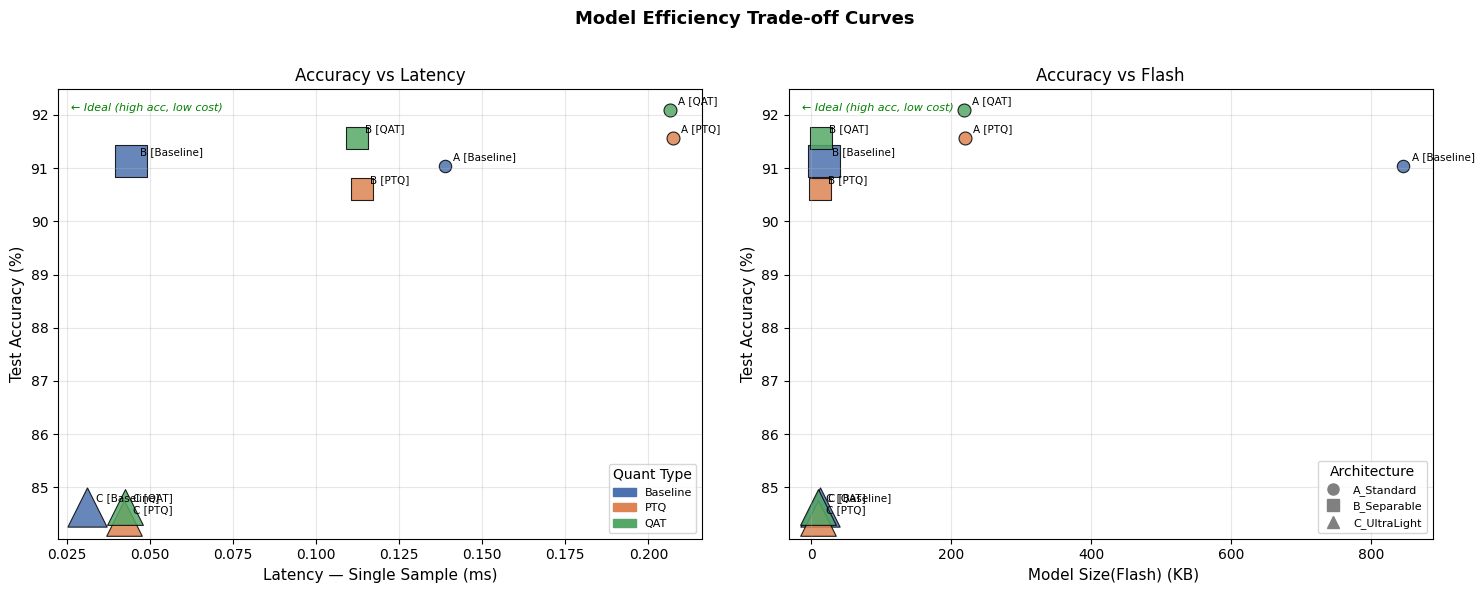

 Trade-off plot saved to /content/drive/MyDrive/speech_commands_project/results/tradeoff_curves.png
 Plot generation log saved to /content/drive/MyDrive/speech_commands_project/logs/plot_generation_log.csv


In [ ]:
type_colors  = {"Baseline": "#4C72B0", "PTQ": "#DD8452", "QAT": "#55A868"}
arch_markers = {
    "Model_A_Standard":  "o",
    "Model_B_Separable": "s",
    "Model_C_UltraLight":"^"
}

df_plot = df_master.copy()

eff_min, eff_max = df_plot["Efficiency Score"].min(), df_plot["Efficiency Score"].max()
df_plot["bubble_size"] = 80 + 720 * (
    (df_plot["Efficiency Score"] - eff_min) / (eff_max - eff_min + 1e-9)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    "Model Efficiency Trade-off Curves\n",
    fontsize=13, fontweight='bold'
)

for ax, x_col, x_label in [
    (axes[0], "Latency (ms)",    "Latency — Single Sample (ms)"),
    (axes[1], "Flash Size (KB)", " Model Size(Flash) (KB)")
]:
    for _, row in df_plot.iterrows():
        marker = arch_markers.get(row["Model"], "o")
        color  = type_colors.get(row["Type"], "gray")

        ax.scatter(
            row[x_col],
            row["Accuracy"] * 100,
            s=row["bubble_size"],
            c=color,
            marker=marker,
            alpha=0.85,
            edgecolors='black',
            linewidths=0.8
        )

        short = (row["Model"]
                 .replace("Model_A_Standard",   "A")
                 .replace("Model_B_Separable",  "B")
                 .replace("Model_C_UltraLight", "C"))
        ax.annotate(
            f"{short} [{row['Type']}]",
            xy=(row[x_col], row["Accuracy"] * 100),
            xytext=(6, 4), textcoords='offset points',
            fontsize=7.5
        )

    ax.set_xlabel(x_label,         fontsize=11)
    ax.set_ylabel("Test Accuracy (%)", fontsize=11)
    ax.set_title(f"Accuracy vs {x_col.split(' ')[0]}", fontsize=12)
    ax.grid(True, alpha=0.3)

    ax.annotate(
        "← Ideal (high acc, low cost)",
        xy=(0.02, 0.97), xycoords='axes fraction',
        fontsize=8, color='green', va='top', style='italic'
    )

# Legends
type_patches = [mpatches.Patch(color=c, label=t) for t, c in type_colors.items()]
marker_lines = [
    plt.Line2D([0], [0], marker=m, color='gray', linestyle='None',
               markersize=8, label=k.replace("Model_", ""))
    for k, m in arch_markers.items()
]
axes[0].legend(handles=type_patches, title="Quant Type",   loc='lower right', fontsize=8)
axes[1].legend(handles=marker_lines, title="Architecture", loc='lower right', fontsize=8)

plt.tight_layout()

plot_path = os.path.join(results_path, 'tradeoff_curves.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f" Trade-off plot saved to {plot_path}")

plot_log_df  = pd.DataFrame([{
    "Plot":       "tradeoff_curves.png",
    "X_axes":     "Latency (ms), Flash Size (KB)",
    "Y_axis":     "Accuracy (%)",
    "Bubble":     "Efficiency Score",
    "Models":     len(df_plot),
    "Types":      ", ".join(df_plot["Type"].unique()),
    "Saved To":   plot_path,
    "Timestamp":  time.strftime("%Y-%m-%d %H:%M:%S")
}])
plot_log_csv = os.path.join(log_path, 'plot_generation_log.csv')
plot_log_df.to_csv(plot_log_csv, index=False)
print(f" Plot generation log saved to {plot_log_csv}")

## **Final Quantitative Comparison Table**

In [ ]:
df_display = df_master.copy()

df_display["Accuracy"] = df_display["Accuracy"].map(lambda x: f"{x:.2%}")

df_display["Parameters"] = df_display["Parameters"].apply(lambda x: f"{int(pd.to_numeric(x, errors='coerce')):,}"
              if pd.to_numeric(x, errors='coerce') is not np.nan else x)

df_display["Flash Size (KB)"] = df_display["Flash Size (KB)"].map(lambda x: f"{x:.2f} KB")

df_display["Memory RAM (KB)"] = df_display["Memory RAM (KB)"].map(lambda x: f"{x:.2f} KB")

df_display["Latency (ms)"] = df_display["Latency (ms)"].map(lambda x: f"{x:.3f} ms")

df_display["Runtime CPU (ms)"] = df_display["Runtime CPU (ms)"].map(lambda x: f"{x:.4f} ms")

df_display["Efficiency Score"] = df_display["Efficiency Score"].map(lambda x: f"{x:.4f}")

cols_ordered = [
    "Model",
    "Type",
    "Parameters",
    "Accuracy",
    "Runtime CPU (ms)",
    "Latency (ms)",
    "Flash Size (KB)",     # model size (flash)
    "Memory RAM (KB)",
    "Efficiency Score"     #computational efficiency
]
df_display = df_display[cols_ordered]

print(" Final Quantitative Comparision ")
display(df_display)

final_display_csv = os.path.join(results_path, 'final_comparison_table.csv')
df_display.to_csv(final_display_csv, index=False)
print(f"\n Final Comparison table saved in {final_display_csv}")

 Final Quantitative Comparision 


,Model,Type,Parameters,Accuracy,Runtime CPU (ms),Latency (ms),Flash Size (KB),Memory RAM (KB),Efficiency Score
0,Model_A_Standard,Baseline,"215,683",91.04%,0.1594 ms,0.139 ms,845.80 KB,1105.17 KB,22.5545
1,Model_B_Separable,Baseline,"3,283",91.14%,0.0523 ms,0.044 ms,18.20 KB,297.98 KB,480.8025
2,Model_C_UltraLight,Baseline,"1,884",84.63%,0.0362 ms,0.031 ms,11.68 KB,187.71 KB,794.3493
3,Model_A_Standard,PTQ,"215,683",91.57%,0.2233 ms,0.207 ms,218.95 KB,281.79 KB,29.8548
4,Model_B_Separable,PTQ,"3,283",90.61%,0.1141 ms,0.114 ms,12.21 KB,79.80 KB,227.8312
5,Model_C_UltraLight,PTQ,"1,884",84.42%,0.0460 ms,0.042 ms,9.70 KB,52.24 KB,640.7859
6,Model_A_Standard,QAT,"215,898",92.10%,0.2175 ms,0.206 ms,217.87 KB,281.79 KB,30.2114
7,Model_B_Separable,QAT,"3,514",91.57%,0.1114 ms,0.112 ms,13.21 KB,79.80 KB,224.4670
8,Model_C_UltraLight,QAT,"2,015",84.63%,0.0478 ms,0.043 ms,9.46 KB,52.24 KB,648.0172



 Final Comparison table saved in /content/drive/MyDrive/speech_commands_project/results/final_comparison_table.csv


## Logging

In [ ]:
if 'final_display_csv' not in dir():
    final_display_csv = os.path.join(results_path, 'final_comparison_table.csv')

summary_log_df = pd.DataFrame([{
    "Total Models Compared": len(df_master),
    "Types":                 ", ".join(df_master["Type"].unique()),
    "Architectures":         ", ".join(df_master["Model"].unique()),
    "Metrics":               "Accuracy, Runtime CPU, Latency, Flash Size, Memory RAM, Efficiency Score",

    "Log: training_summary":     os.path.join(log_path, 'training_summary_log.csv'),
    "Log: baseline_export":      os.path.join(log_path, 'baseline_export_log.csv'),
    "Log: ptq_process":          os.path.join(log_path, 'ptq_process_summary.csv'),
    "Log: qat_process":          os.path.join(log_path, 'qat_process_summary.csv'),
    "Log: benchmark_run":        os.path.join(log_path, 'benchmark_run_log.csv'),
    "Log: accuracy_summary":     os.path.join(log_path, 'accuracy_summary_log.csv'),
    "Log: plot_generation":      os.path.join(log_path, 'plot_generation_log.csv'),

    "Result: master_benchmark":  os.path.join(results_path, 'final_unified_benchmark.csv'),
    "Result: baseline_results":  os.path.join(results_path, 'baseline_benchmark_results.csv'),
    "Result: ptq_results":       os.path.join(results_path, 'ptq_benchmark_results.csv'),
    "Result: qat_results":       os.path.join(results_path, 'qat_benchmark_results.csv'),
    "Result: tradeoff_plot":     os.path.join(results_path, 'tradeoff_curves.png'),
    "Result: final_table":       final_display_csv,
    "Generated At":              time.strftime("%Y-%m-%d %H:%M:%S")
}])
summary_log_csv = os.path.join(log_path, 'final_comparison_log.csv')
summary_log_df.to_csv(summary_log_csv, index=False)
print(f" Final comparison log (file index) saved in {summary_log_csv}")

 Final comparison log (file index) saved in /content/drive/MyDrive/speech_commands_project/logs/final_comparison_log.csv
